Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      losses/val_loss      │    0.21058697998523712    │
│   val_metrics/accuracy    │    0.6822469234466553     │
│      val_metrics/f1       │    0.6801908016204834     │
│     val_metrics/miou      │    0.5644864439964294     │
│   val_metrics/precision   │    0.6789988279342651     │
│    val_metrics/recall     │    0.6822469234466553     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     losses/test_loss      │     0.251521497964859     │
│   test_metrics/accuracy   │    0.6762509346008301     │
│      test_metrics/f1      │    0.6669750213623047     │
│     test_metrics/miou     │    0.5656092762947083     │
│  test_metrics/precision   │    0.6635276675224304     │
│    test_metrics/recall    │    0.6762509346008301     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

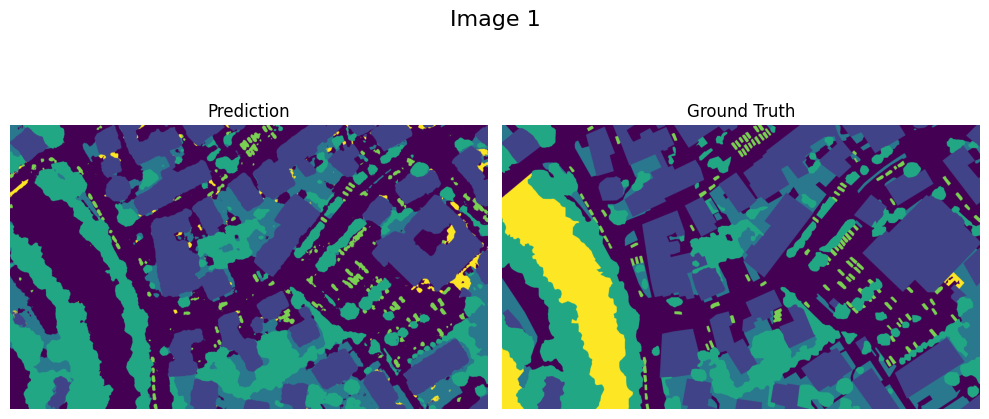

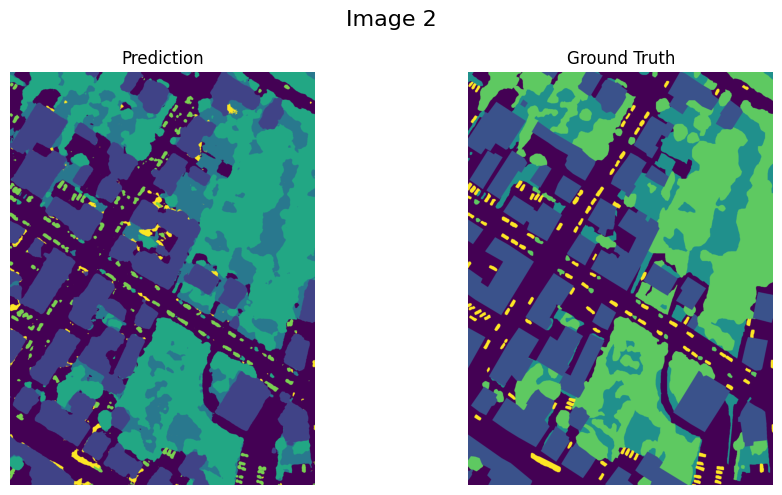

In [ ]:
import lightning as L
from src.config import TrainConfig
from src.datamodules import HFDataModule
from src.models import get_model
from src.segmentors import GridSegmentor
import yaml
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings("ignore")

warnings.filterwarnings(
    "ignore",
    message="You called `self.log",
)

L.seed_everything(42)


def plot_comparison(model_output):
    for idx, image in enumerate(model_output, start=1):
        pred = image[0].permute(1, 2, 0).numpy()
        gt = image[1].permute(1, 2, 0).numpy()

        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(pred)
        axes[0].set_title("Prediction")
        axes[0].axis("off")

        axes[1].imshow(gt)
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")
        fig.suptitle(f"Image {idx}", fontsize=16)

        plt.tight_layout()
        plt.show()


def test_checkpoint(checkpoint_to_validate: str, config_path: str):
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    cfg = TrainConfig(**config)
    model = get_model(cfg.model, **cfg.model_kwargs.model_dump())

    train_path = f"{cfg.dataset_name}_HF/{cfg.dataset_name}_train_patches-{cfg.patch_size}x{cfg.patch_size}/*"
    val_path = f"{cfg.dataset_name}_HF/{cfg.dataset_name}_validation/*"
    test_path = f"{cfg.dataset_name}_HF/{cfg.dataset_name}_test/*"

    segmentation_model = GridSegmentor.load_from_checkpoint(
        checkpoint_to_validate,
        model=model,
        n_classes=cfg.n_classes,
        criterion=cfg.get_loss(),
        batch_size=cfg.batch_size,
        patch_size=cfg.patch_size,
        overlap=cfg.overlap,
        lr=cfg.lr,
        weight_decay=cfg.weight_decay,
        weights_only=False,
    )

    dm = HFDataModule(
        train_path=train_path,
        val_path=val_path,
        test_path=test_path,
        batch_size=cfg.batch_size,
    )

    trainer = L.Trainer(
        enable_model_summary=True,
        max_epochs=cfg.max_epochs,
        accelerator="gpu",
        devices=1,
        enable_progress_bar=True,
        accumulate_grad_batches=cfg.grad_accumulation_batches,
        log_every_n_steps=1,
        precision=cfg.precision,
        logger=False,
    )

    return trainer, segmentation_model, dm


CHECKPOINT_TO_VALIDATE = (
    "l_checkpoints/Vaihingen/segnet/v1/best_accuracy_val_metrics/accuracy=0.6822.ckpt"
)
CONFIG_PATH = "config_files/segnet_vaihingen_v1.yaml"
trainer, segmentation_model, dm = test_checkpoint(CHECKPOINT_TO_VALIDATE, CONFIG_PATH)

validation = trainer.validate(model=segmentation_model, datamodule=dm)
testing = trainer.test(model=segmentation_model, datamodule=dm)
output = trainer.predict(segmentation_model, dm)
plot_comparison(output)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      losses/val_loss      │    0.21240456402301788    │
│   val_metrics/accuracy    │     0.668563961982727     │
│      val_metrics/f1       │    0.6806492209434509     │
│     val_metrics/miou      │    0.5663980841636658     │
│   val_metrics/precision   │    0.6983778476715088     │
│    val_metrics/recall     │     0.668563961982727     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     losses/test_loss      │    0.2539914548397064     │
│   test_metrics/accuracy   │    0.6614318490028381     │
│      test_metrics/f1      │    0.6631230115890503     │
│     test_metrics/miou     │    0.5588963031768799     │
│  test_metrics/precision   │    0.6790966987609863     │
│    test_metrics/recall    │    0.6614318490028381     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

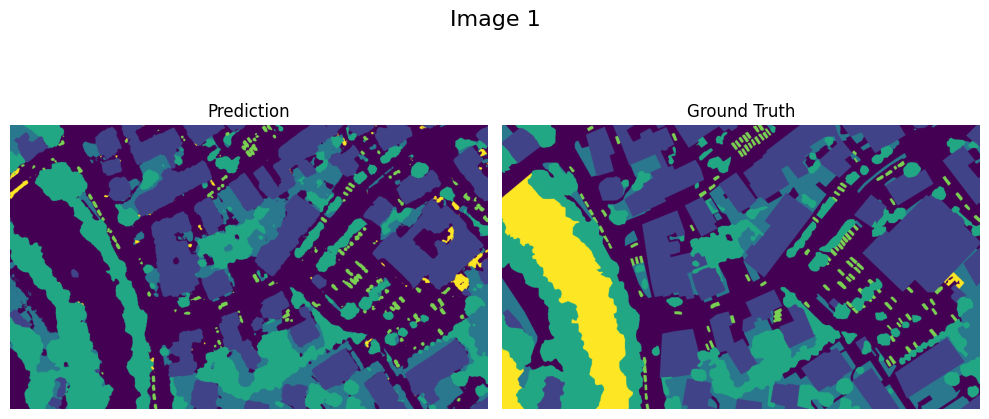

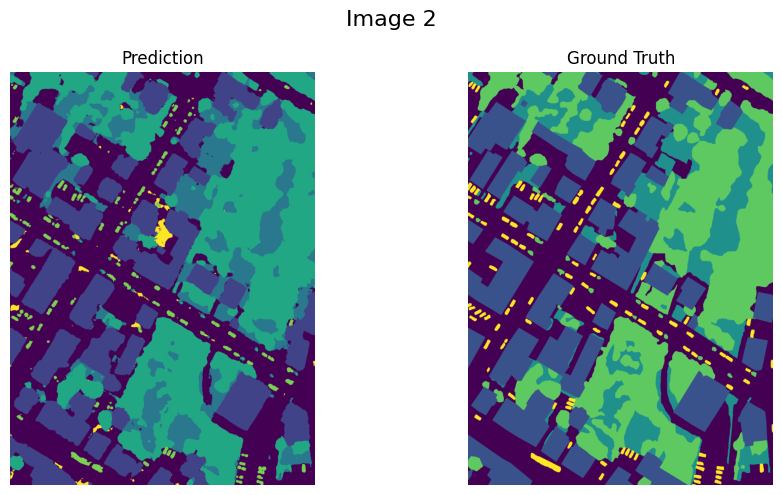

In [2]:
CHECKPOINT_TO_VALIDATE = (
    "l_checkpoints/Vaihingen/segnet/v1/best_miou_val_metrics/miou=0.5664.ckpt"
)
CONFIG_PATH = "config_files/segnet_vaihingen_v1.yaml"
trainer, segmentation_model, dm = test_checkpoint(CHECKPOINT_TO_VALIDATE, CONFIG_PATH)

validation = trainer.validate(model=segmentation_model, datamodule=dm)
testing = trainer.test(model=segmentation_model, datamodule=dm)
output = trainer.predict(segmentation_model, dm)
plot_comparison(output)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      losses/val_loss      │    0.21240456402301788    │
│   val_metrics/accuracy    │     0.668563961982727     │
│      val_metrics/f1       │    0.6806492209434509     │
│     val_metrics/miou      │    0.5663980841636658     │
│   val_metrics/precision   │    0.6983778476715088     │
│    val_metrics/recall     │     0.668563961982727     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     losses/test_loss      │    0.2539914548397064     │
│   test_metrics/accuracy   │    0.6614318490028381     │
│      test_metrics/f1      │    0.6631230115890503     │
│     test_metrics/miou     │    0.5588963031768799     │
│  test_metrics/precision   │    0.6790966987609863     │
│    test_metrics/recall    │    0.6614318490028381     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

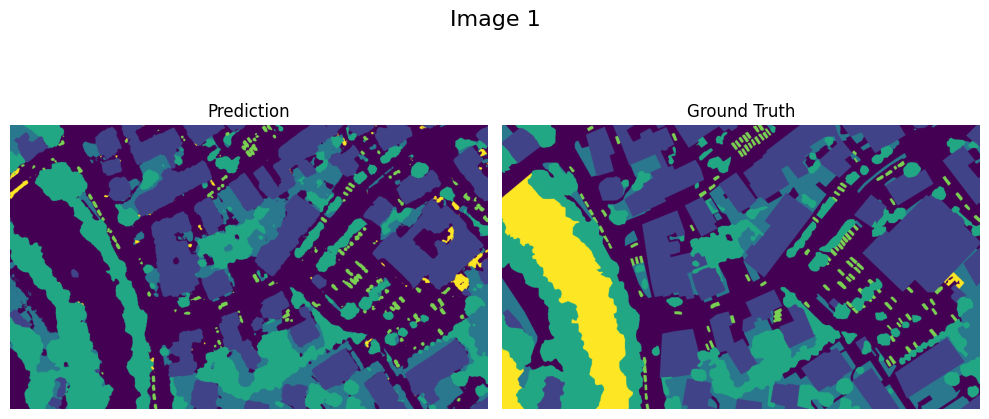

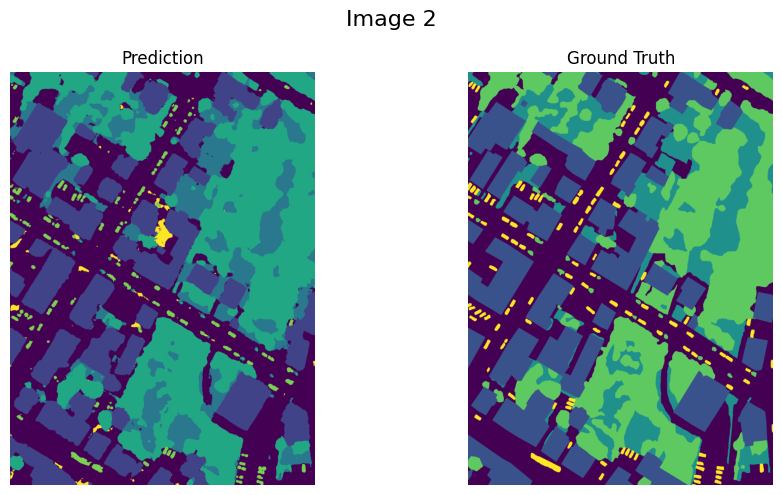

In [7]:
CHECKPOINT_TO_VALIDATE = (
    "l_checkpoints/Vaihingen/segnet/v1/best_f1_val_metrics/f1=0.6806.ckpt"
)
CONFIG_PATH = "config_files/segnet_vaihingen_v1.yaml"
trainer, segmentation_model, dm = test_checkpoint(CHECKPOINT_TO_VALIDATE, CONFIG_PATH)

validation = trainer.validate(model=segmentation_model, datamodule=dm)
testing = trainer.test(model=segmentation_model, datamodule=dm)
output = trainer.predict(segmentation_model, dm)
plot_comparison(output)

## Segformer

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      losses/val_loss      │    0.16480322182178497    │
│   val_metrics/accuracy    │    0.7136282324790955     │
│      val_metrics/f1       │    0.7160732746124268     │
│     val_metrics/miou      │    0.6902220249176025     │
│   val_metrics/precision   │    0.7188876867294312     │
│    val_metrics/recall     │    0.7136282324790955     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     losses/test_loss      │    0.20386150479316711    │
│   test_metrics/accuracy   │    0.7058494091033936     │
│      test_metrics/f1      │    0.7015098333358765     │
│     test_metrics/miou     │    0.6699005961418152     │
│  test_metrics/precision   │    0.6995063424110413     │
│    test_metrics/recall    │    0.7058494091033936     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

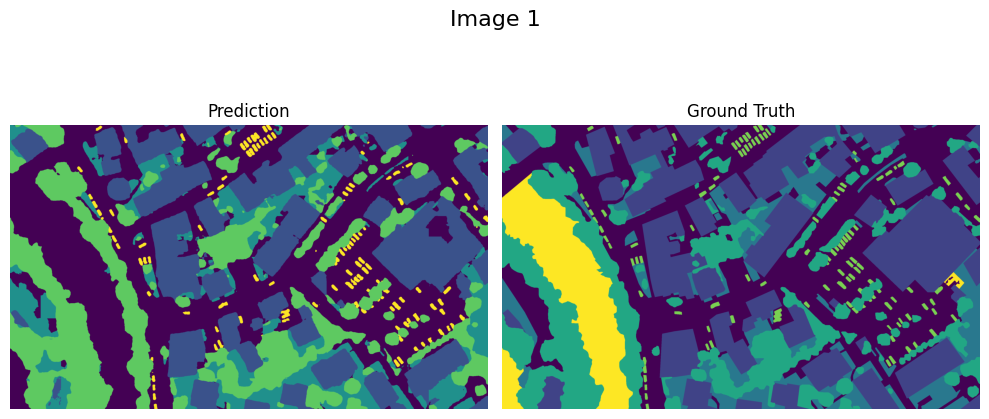

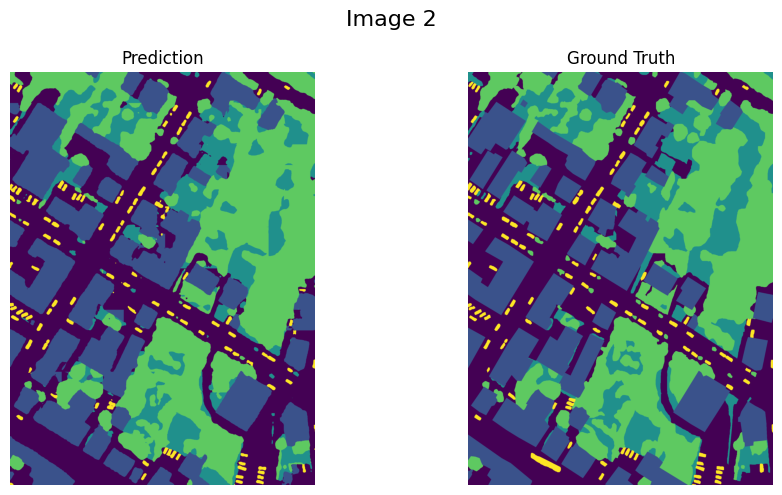

In [3]:
CHECKPOINT_TO_VALIDATE = (
    "l_checkpoints/Vaihingen/segformer/v1/best_miou_val_metrics/miou=0.6902.ckpt"
)
CONFIG_PATH = "config_files/segformer_vaihingen_v1.yaml"
trainer, segmentation_model, dm = test_checkpoint(CHECKPOINT_TO_VALIDATE, CONFIG_PATH)

validation = trainer.validate(model=segmentation_model, datamodule=dm)
testing = trainer.test(model=segmentation_model, datamodule=dm)
output = trainer.predict(segmentation_model, dm)
plot_comparison(output)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      losses/val_loss      │    0.1787208616733551     │
│   val_metrics/accuracy    │    0.7205591201782227     │
│      val_metrics/f1       │    0.7484503388404846     │
│     val_metrics/miou      │    0.6337393522262573     │
│   val_metrics/precision   │    0.8285425901412964     │
│    val_metrics/recall     │    0.7205591201782227     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     losses/test_loss      │    0.20895171165466309    │
│   test_metrics/accuracy   │    0.7345706224441528     │
│      test_metrics/f1      │    0.7701143026351929     │
│     test_metrics/miou     │    0.6301731467247009     │
│  test_metrics/precision   │    0.8778799176216125     │
│    test_metrics/recall    │    0.7345706224441528     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

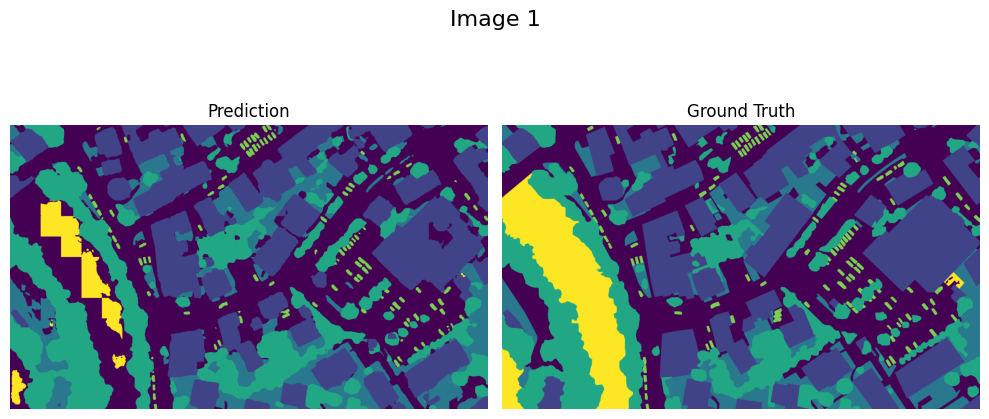

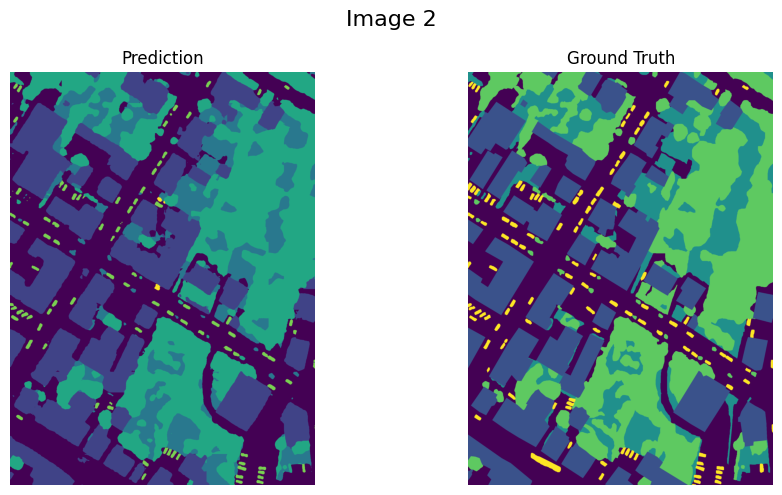

In [5]:
CHECKPOINT_TO_VALIDATE = (
    "l_checkpoints/Vaihingen/segformer/v1/best_f1_val_metrics/f1=0.7485.ckpt"
)
CONFIG_PATH = "config_files/segformer_vaihingen_v1.yaml"
trainer, segmentation_model, dm = test_checkpoint(CHECKPOINT_TO_VALIDATE, CONFIG_PATH)

validation = trainer.validate(model=segmentation_model, datamodule=dm)
testing = trainer.test(model=segmentation_model, datamodule=dm)
output = trainer.predict(segmentation_model, dm)
plot_comparison(output)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      losses/val_loss      │    0.17581868171691895    │
│   val_metrics/accuracy    │    0.7027886509895325     │
│      val_metrics/f1       │    0.7100273370742798     │
│     val_metrics/miou      │    0.6287790536880493     │
│   val_metrics/precision   │    0.8401843309402466     │
│    val_metrics/recall     │    0.7027886509895325     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     losses/test_loss      │    0.20310500264167786    │
│   test_metrics/accuracy   │    0.7072615027427673     │
│      test_metrics/f1      │    0.7054516077041626     │
│     test_metrics/miou     │    0.6189234852790833     │
│  test_metrics/precision   │    0.7856422662734985     │
│    test_metrics/recall    │    0.7072615027427673     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

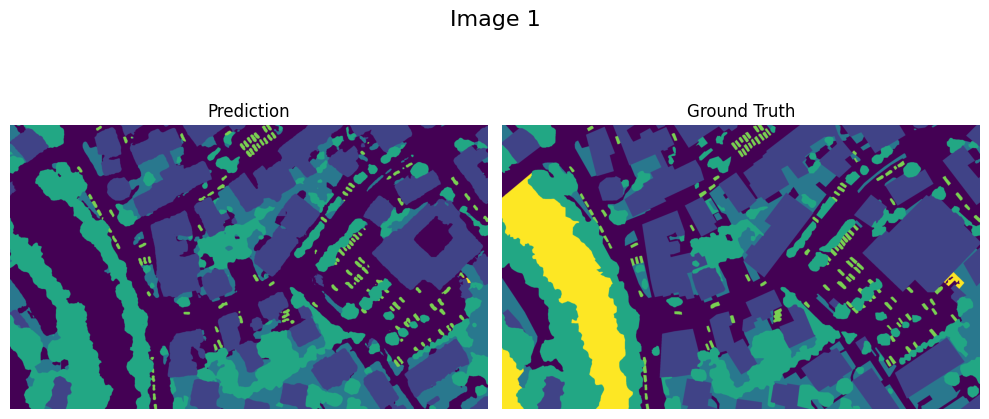

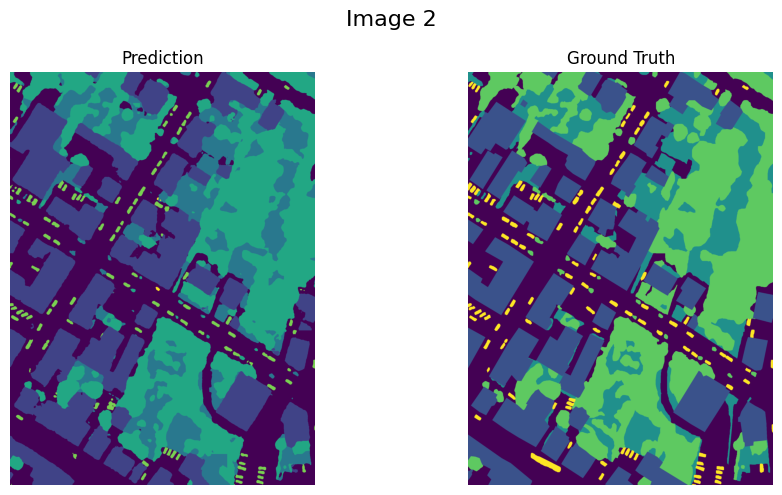

In [6]:
CHECKPOINT_TO_VALIDATE = "l_checkpoints/Vaihingen/segformer/v1/best_precision_val_metrics/precision=0.8402.ckpt"
CONFIG_PATH = "config_files/segformer_vaihingen_v1.yaml"
trainer, segmentation_model, dm = test_checkpoint(CHECKPOINT_TO_VALIDATE, CONFIG_PATH)

validation = trainer.validate(model=segmentation_model, datamodule=dm)
testing = trainer.test(model=segmentation_model, datamodule=dm)
output = trainer.predict(segmentation_model, dm)
plot_comparison(output)

## Unet

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      losses/val_loss      │    0.16643288731575012    │
│   val_metrics/accuracy    │    0.7170840501785278     │
│      val_metrics/f1       │    0.7171867489814758     │
│     val_metrics/miou      │    0.6878519654273987     │
│   val_metrics/precision   │    0.7179863452911377     │
│    val_metrics/recall     │    0.7170840501785278     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     losses/test_loss      │    0.20723359286785126    │
│   test_metrics/accuracy   │    0.7051613926887512     │
│      test_metrics/f1      │    0.7032777070999146     │
│     test_metrics/miou     │    0.6722345352172852     │
│  test_metrics/precision   │    0.7049438953399658     │
│    test_metrics/recall    │    0.7051613926887512     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

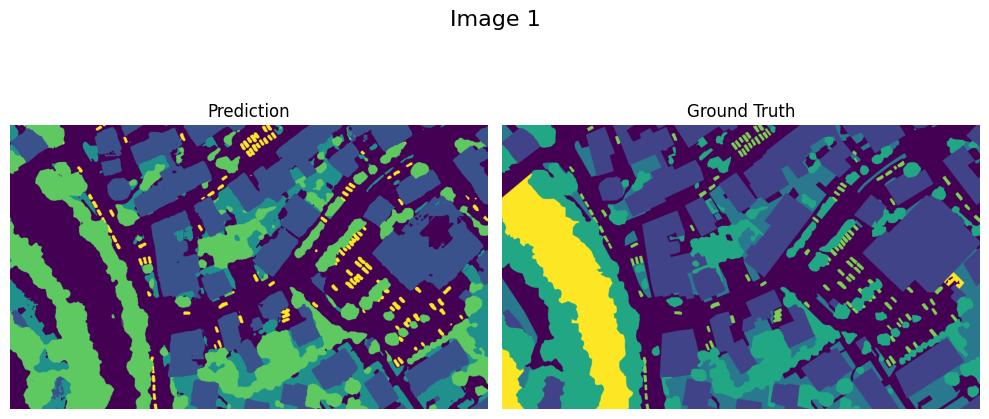

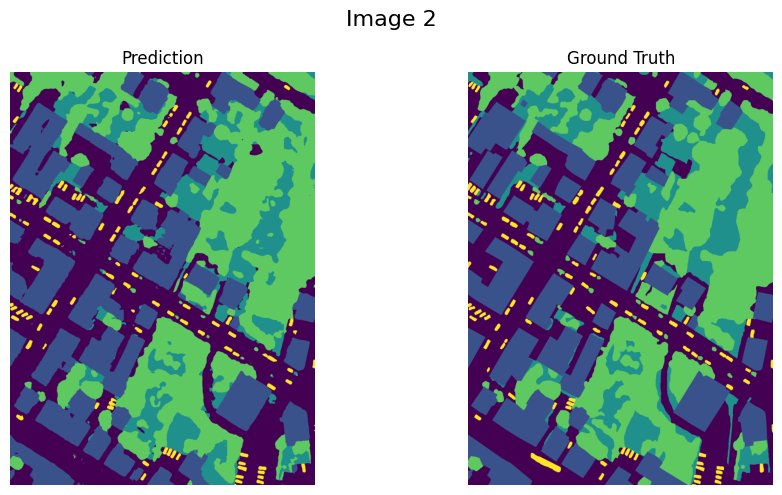

In [4]:
CHECKPOINT_TO_VALIDATE = (
    "l_checkpoints/Vaihingen/unet/v1/best_miou_val_metrics/miou=0.6879.ckpt"
)
CONFIG_PATH = "config_files/unet_vaihingen_v1.yaml"
trainer, segmentation_model, dm = test_checkpoint(CHECKPOINT_TO_VALIDATE, CONFIG_PATH)

validation = trainer.validate(model=segmentation_model, datamodule=dm)
testing = trainer.test(model=segmentation_model, datamodule=dm)
output = trainer.predict(segmentation_model, dm)
plot_comparison(output)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      losses/val_loss      │    0.16077931225299835    │
│   val_metrics/accuracy    │    0.7184599041938782     │
│      val_metrics/f1       │    0.7195627689361572     │
│     val_metrics/miou      │    0.6447627544403076     │
│   val_metrics/precision   │    0.7208603024482727     │
│    val_metrics/recall     │    0.7184599041938782     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     losses/test_loss      │    0.1960163414478302     │
│   test_metrics/accuracy   │    0.7197830677032471     │
│      test_metrics/f1      │    0.7128106355667114     │
│     test_metrics/miou     │    0.6302641034126282     │
│  test_metrics/precision   │    0.7082675695419312     │
│    test_metrics/recall    │    0.7197830677032471     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

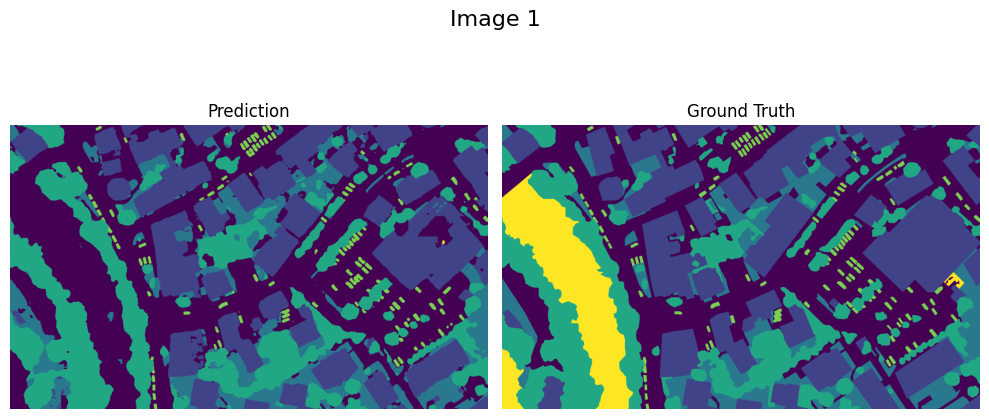

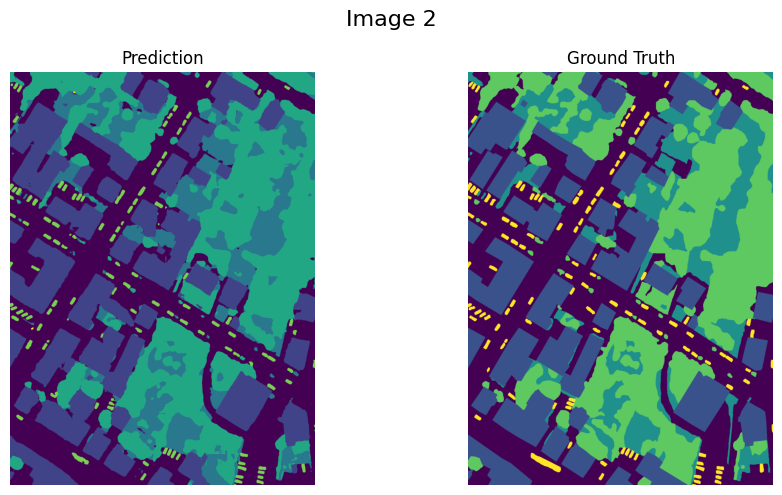

In [8]:
CHECKPOINT_TO_VALIDATE = (
    "l_checkpoints/Vaihingen/unet/v1/best_f1_val_metrics/f1=0.7196.ckpt"
)
CONFIG_PATH = "config_files/unet_vaihingen_v1.yaml"
trainer, segmentation_model, dm = test_checkpoint(CHECKPOINT_TO_VALIDATE, CONFIG_PATH)

validation = trainer.validate(model=segmentation_model, datamodule=dm)
testing = trainer.test(model=segmentation_model, datamodule=dm)
output = trainer.predict(segmentation_model, dm)
plot_comparison(output)

## Unetpp

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      losses/val_loss      │    0.16168051958084106    │
│   val_metrics/accuracy    │    0.7166297435760498     │
│      val_metrics/f1       │    0.7180745601654053     │
│     val_metrics/miou      │    0.6907062530517578     │
│   val_metrics/precision   │    0.7197771072387695     │
│    val_metrics/recall     │    0.7166297435760498     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     losses/test_loss      │    0.19526076316833496    │
│   test_metrics/accuracy   │    0.7159964442253113     │
│      test_metrics/f1      │    0.7119007110595703     │
│     test_metrics/miou     │    0.6285176277160645     │
│  test_metrics/precision   │    0.7105921506881714     │
│    test_metrics/recall    │    0.7159964442253113     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

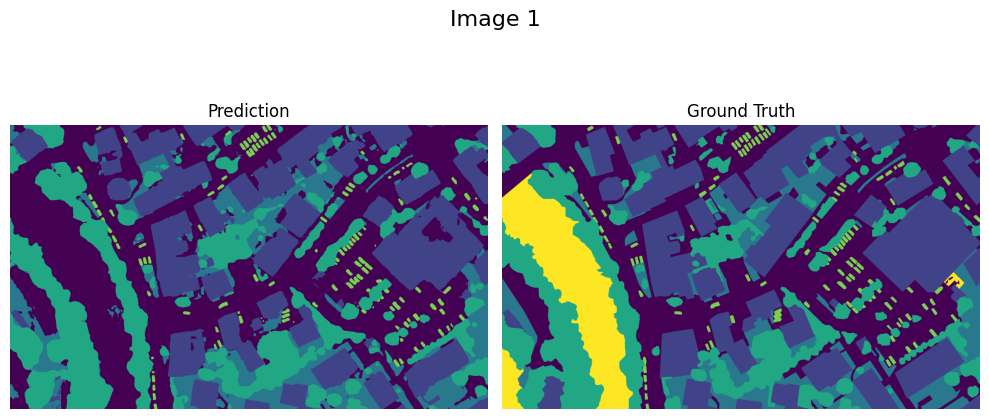

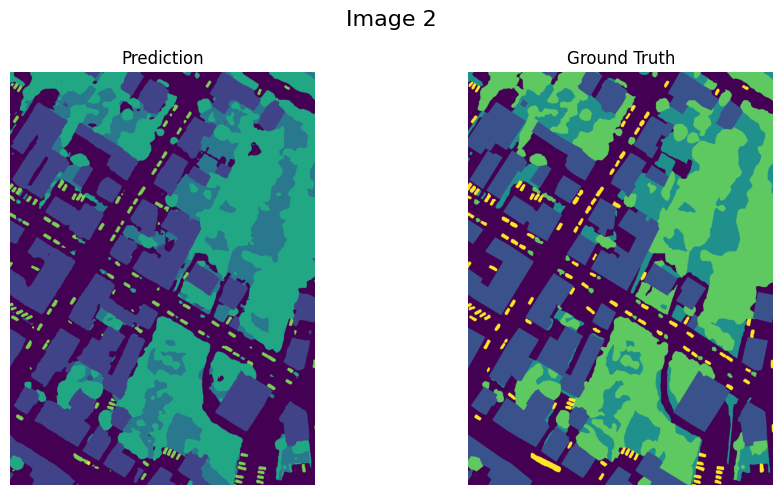

In [10]:
CHECKPOINT_TO_VALIDATE = (
    "l_checkpoints/Vaihingen/unetpp/v1/best_miou_val_metrics/miou=0.6907.ckpt"
)
CONFIG_PATH = "config_files/unetpp_vaihingen_v1.yaml"
trainer, segmentation_model, dm = test_checkpoint(CHECKPOINT_TO_VALIDATE, CONFIG_PATH)

validation = trainer.validate(model=segmentation_model, datamodule=dm)
testing = trainer.test(model=segmentation_model, datamodule=dm)
output = trainer.predict(segmentation_model, dm)
plot_comparison(output)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      losses/val_loss      │    0.16261020302772522    │
│   val_metrics/accuracy    │    0.7142382264137268     │
│      val_metrics/f1       │    0.7181676030158997     │
│     val_metrics/miou      │    0.6657565832138062     │
│   val_metrics/precision   │    0.7227072715759277     │
│    val_metrics/recall     │    0.7142382264137268     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     losses/test_loss      │    0.20033247768878937    │
│   test_metrics/accuracy   │    0.7102351784706116     │
│      test_metrics/f1      │    0.7081530094146729     │
│     test_metrics/miou     │    0.6798822283744812     │
│  test_metrics/precision   │    0.7097921371459961     │
│    test_metrics/recall    │    0.7102351784706116     │
└───────────────────────────┴───────────────────────────┘

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

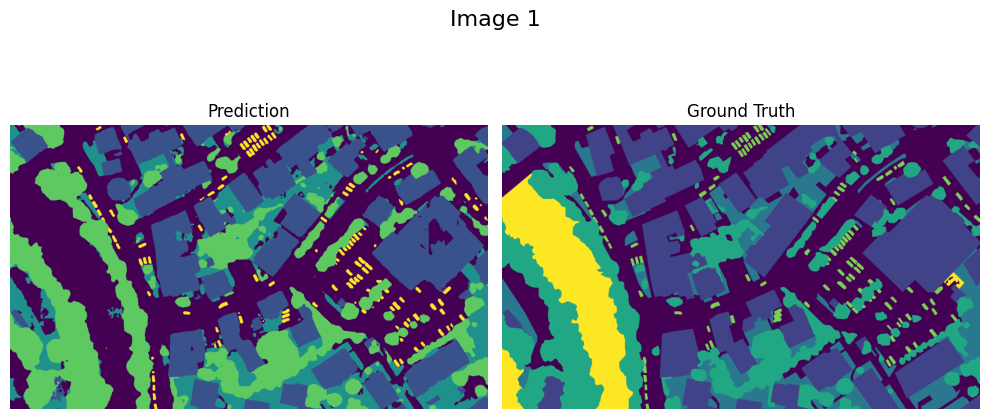

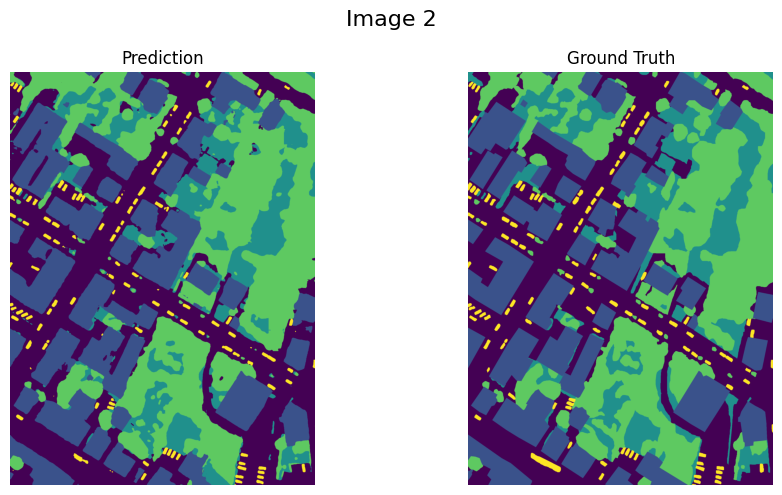

In [11]:
CHECKPOINT_TO_VALIDATE = (
    "l_checkpoints/Vaihingen/unetpp/v1/best_f1_val_metrics/f1=0.7182.ckpt"
)
CONFIG_PATH = "config_files/unetpp_vaihingen_v1.yaml"
trainer, segmentation_model, dm = test_checkpoint(CHECKPOINT_TO_VALIDATE, CONFIG_PATH)

validation = trainer.validate(model=segmentation_model, datamodule=dm)
testing = trainer.test(model=segmentation_model, datamodule=dm)
output = trainer.predict(segmentation_model, dm)
plot_comparison(output)